# 24-Hour Fuel Procurement, Inventory, and Power Dispacth LP

This notebook formulates a **linear programming (LP)** problem for the 24-hour operation of three thermal generators: **Coal**, **Gas**, and **Diesel**.

The optimizer simultaneously decides how much fuel to **buy**, how much fuel to keep in **inventory**, and how much **power** each generator should produce.

Fuel inventories and deliveries are measured in **tons**, while the connection between fuel mass and electrical generation is made through the generator heat rate and fuel heating value.

For generator $g$ and hour $t$:

$$\text{Fuel used}_{g,t}=\frac{h_g P_{g,t}\Delta t}{H_g}$$

where $h_g$ is the heat rate in GJ/MWh and $H_g$ is the fuel heating value in GJ/ton.

## 1. Mathematical formulation

### Decision variables

* $P_{g,t}$ is the power output of generator $g$ during hour $t$ [MW]
* $B_{g,t}$ is the fuel bought for generator $g$ during hour $t$ [tons]
* $M_{g,t}$ is end-of-hour fuel inventory for generator $g$ [tons]

### Fixed parameters

* $D_t$ denotes electricity demand during hour $t$ [MW]
* $P_g^{\max}$ is the maximum generator output [MW]. $P_g^{\min}$ is zero.
* $h_g$ is the heat rate of generator $g$ [GJ/MWh]
* $H_g$ is the fuel heating value of the fuel for generator $g$ [GJ/ton]
* $c_{g,t}$ is the purchase price forecast of the fuel for generator $g$ at time $t$ [PHP/ton]
* $M_{g,0}$ is the initial fuel inventory for generator $g$ [ton]
* $M_g^{\max}$ is the maximum fuel inventory for the fuel for generator $g$ [ton]
* $B_{g,t}^{max}$ is the maximum allowable fuel purchase for generator $g$ at time $t$ [ton]
* $\Delta t$ is the duration of each time period = 1 hour [h]

### Objective function

$$ \min \sum_t\sum_g c_{g,t}B_{g,t} $$

### Constraints

Hourly demand balance:

$$\sum_g P_{g,t}=D_t \qquad \forall t$$

Generator capacity:

$$0\le P_{g,t}\le P_g^{\max}$$

Fuel inventory balance:

$$M_{g,1}=M_{g,0}+B_{g,1}-\frac{h_gP_{g,1}\Delta t}{H_g}, \qquad t=1 $$

$$M_{g,t}=M_{g,t-1}+B_{g,t}-\frac{h_gP_{g,t}\Delta t}{H_g},\qquad t=2,\ldots,24$$

Fuel storage capacity:

$$0\le M_{g,t}\le M_g^{\max}$$

Purchase limit:

$$ 0\le B_{g,t}\le B_{g,t}^{\max} $$

In [1]:
import pyomo.environ as pyo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Sets and fixed parameters

In [2]:
G = ['Coal', 'Gas', 'Diesel']
T = list(range(1, 25))
dt = 1.0

Pmax = {'Coal': 100, 'Gas': 80, 'Diesel': 50}
heat_rate = {'Coal': 10.0, 'Gas': 7.0, 'Diesel': 9.0}
heating_value = {'Coal': 25.0, 'Gas': 50.0, 'Diesel': 43.0}

M0 = {'Coal': 35.0, 'Gas': 12.0, 'Diesel': 8.0}
Mmax = {'Coal': 95.0, 'Gas': 35.0, 'Diesel': 25.0}
Bmax_const = {'Coal': 42.0, 'Gas': 13.0, 'Diesel': 10.0}
Bmax = {(g,t): Bmax_const[g] for g in G for t in T}

demand_values = [105,100,98,96,100,110,125,145,160,170,175,180,178,172,165,160,168,182,195,190,175,155,135,118]
demand = {t: demand_values[t-1] for t in T}

coal_price = [4200,4150,4100,4050,4100,4200,4400,4550,4700,4850,5000,5150,5200,5100,4950,4800,4700,4900,5250,5350,5150,4850,4550,4350]
gas_price =    [26000,25800,25500,25200,25400,26000,27000,28000,29200,30500,31500,31800,31000,30500,28200,27600,26400,24800,25400,24000,23600,23500,23400,23200]
diesel_price = [17500,17200,17000,16800,17000,17600,18500,19400,20500,21600,22400,22500,22800,22900,24200,26700,27400,30500,30800,31200,31000,31500,31800,31500]


fuel_price = {}
for t in T:
    fuel_price['Coal',t] = coal_price[t-1]
    fuel_price['Gas',t] = gas_price[t-1]
    fuel_price['Diesel',t] = diesel_price[t-1]

## 3. Build the Pyomo LP

In [3]:
model = pyo.ConcreteModel()
model.G = pyo.Set(initialize=G)
model.T = pyo.Set(initialize=T)

model.P = pyo.Var(model.G, model.T, domain=pyo.NonNegativeReals)
model.B = pyo.Var(model.G, model.T, domain=pyo.NonNegativeReals)
model.M = pyo.Var(model.G, model.T, domain=pyo.NonNegativeReals)

def objective_rule(model):
    return sum(fuel_price[g,t]*model.B[g,t] for g in model.G for t in model.T)
model.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

def demand_rule(model,t):
    return sum(model.P[g,t] for g in model.G) == demand[t]
model.demand_balance = pyo.Constraint(model.T, rule=demand_rule)

def capacity_rule(model,g,t):
    return model.P[g,t] <= Pmax[g]
model.capacity = pyo.Constraint(model.G, model.T, rule=capacity_rule)

def purchase_limit_rule(model,g,t):
    return model.B[g,t] <= Bmax[g,t]
model.purchase_limit = pyo.Constraint(model.G, model.T, rule=purchase_limit_rule)

def inventory_rule(model,g,t):
    fuel_used = heat_rate[g]*model.P[g,t]*dt/heating_value[g]
    if t == 1:
        return model.M[g,t] == M0[g] + model.B[g,t] - fuel_used
    return model.M[g,t] == model.M[g,t-1] + model.B[g,t] - fuel_used
model.inventory_balance = pyo.Constraint(model.G, model.T, rule=inventory_rule)

def inventory_capacity_rule(model,g,t):
    return model.M[g,t] <= Mmax[g]
model.inventory_capacity = pyo.Constraint(model.G, model.T, rule=inventory_capacity_rule)

## 4. Solve the LP

In [4]:
solver = pyo.SolverFactory('glpk')
results = solver.solve(model, tee=False)

print('Solver status:', results.solver.status)
print('Termination condition:', results.solver.termination_condition)

if results.solver.termination_condition != pyo.TerminationCondition.optimal:
    raise RuntimeError('The LP did not return an optimal solution.')

print(f"Total fuel procurement cost = PHP {pyo.value(model.objective):,.2f}")

Solver status: ok
Termination condition: optimal
Total fuel procurement cost = PHP 8,030,444.22


## 5. Extract the 24-hour optimal schedule

In [5]:
rows = []
for t in T:
    row = {'Hour': t, 'Demand_MW': demand[t]}
    for g in G:
        power = pyo.value(model.P[g,t])
        bought = pyo.value(model.B[g,t])
        inventory = pyo.value(model.M[g,t])
        utilized = heat_rate[g]*power*dt/heating_value[g]
        row[f'{g}_Power_MW'] = power
        row[f'{g}_Bought_t'] = bought
        row[f'{g}_Utilized_t'] = utilized
        row[f'{g}_Inventory_t'] = inventory
        row[f'{g}_Fuel_Price_PHP_per_t'] = fuel_price[g,t]
    rows.append(row)

df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
display(df.round(2))

,Hour,Demand_MW,Coal_Power_MW,Coal_Bought_t,Coal_Utilized_t,Coal_Inventory_t,Coal_Fuel_Price_PHP_per_t,Gas_Power_MW,Gas_Bought_t,Gas_Utilized_t,Gas_Inventory_t,Gas_Fuel_Price_PHP_per_t,Diesel_Power_MW,Diesel_Bought_t,Diesel_Utilized_t,Diesel_Inventory_t,Diesel_Fuel_Price_PHP_per_t
0,1,105,100.0,42.0,40.0,37.0,4200,5.00,0.00,0.70,11.30,26000,0.00,0.0,0.00,8.00,17500
1,2,100,100.0,42.0,40.0,39.0,4150,0.00,0.00,0.00,11.30,25800,0.00,0.0,0.00,8.00,17200
2,3,98,98.0,42.0,39.2,41.8,4100,0.00,0.00,0.00,11.30,25500,0.00,0.0,0.00,8.00,17000
3,4,96,96.0,42.0,38.4,45.4,4050,0.00,13.00,0.00,24.30,25200,0.00,10.0,0.00,18.00,16800
4,5,100,100.0,42.0,40.0,47.4,4100,0.00,10.70,0.00,35.00,25400,0.00,7.0,0.00,25.00,17000
5,6,110,100.0,42.0,40.0,49.4,4200,10.00,1.40,1.40,35.00,26000,0.00,-0.0,0.00,25.00,17600
6,7,125,100.0,42.0,40.0,51.4,4400,25.00,3.50,3.50,35.00,27000,0.00,-0.0,0.00,25.00,18500
7,8,145,100.0,42.0,40.0,53.4,4550,45.00,6.30,6.30,35.00,28000,0.00,-0.0,0.00,25.00,19400
8,9,160,100.0,42.0,40.0,55.4,4700,60.00,8.40,8.40,35.00,29200,0.00,0.0,0.00,25.00,20500
9,10,170,100.0,42.0,40.0,57.4,4850,32.56,4.56,4.56,35.00,30500,37.44,0.0,7.84,17.16,21600


## 6. Plot fuel inventory versus utilized fuel

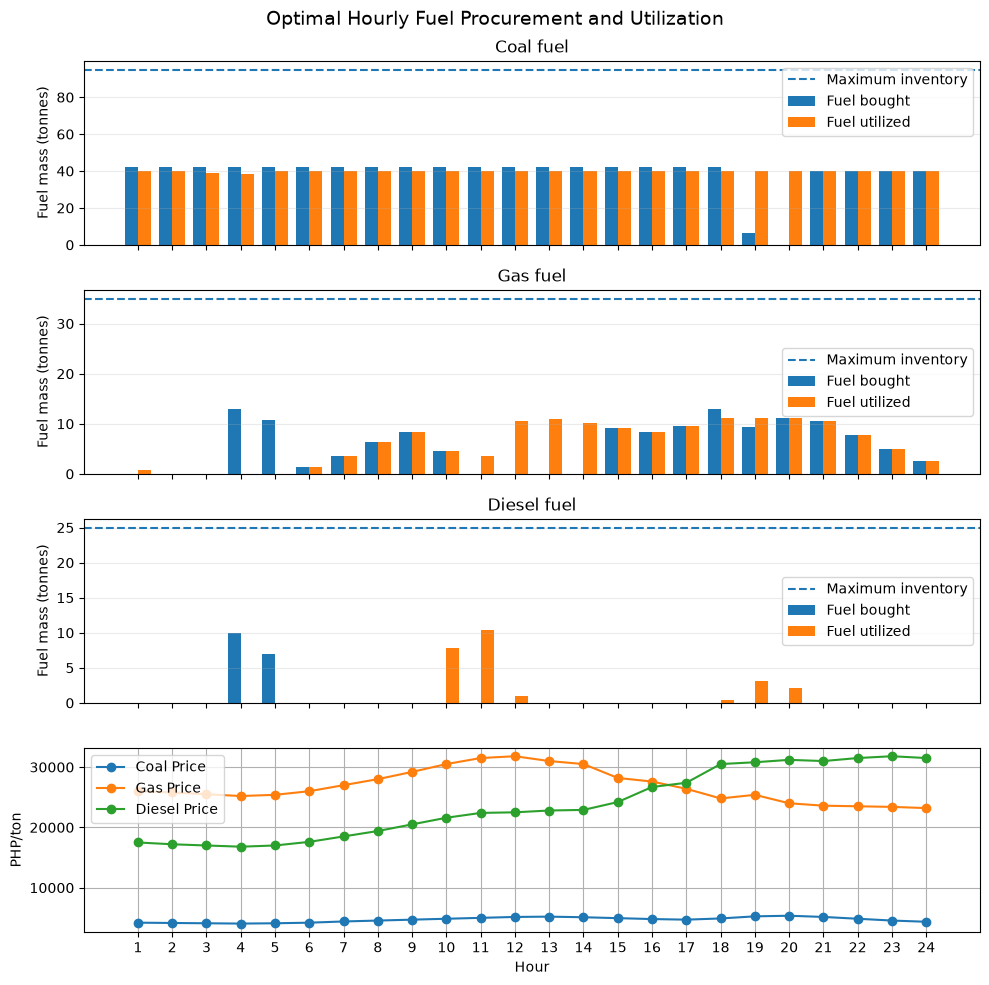

In [6]:
hours = df['Hour'].to_numpy()
bar_width = 0.38

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

for ax, g in zip(axes, G):
    bought = df[f'{g}_Bought_t'].to_numpy()
    utilized = df[f'{g}_Utilized_t'].to_numpy()

    ax.bar(hours - bar_width/2, bought, width=bar_width, label='Fuel bought')
    ax.bar(hours + bar_width/2, utilized, width=bar_width, label='Fuel utilized')
    ax.axhline(Mmax[g], linestyle='--', linewidth=1.5, label='Maximum inventory')

    ax.set_title(f'{g} fuel')
    ax.set_ylabel('Fuel mass (tonnes)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()

axes[-1].plot(hours, coal_price, 'o-', label="Coal Price")
axes[-1].plot(hours, gas_price, 'o-', label="Gas Price")
axes[-1].plot(hours, diesel_price, 'o-', label="Diesel Price")
axes[-1].legend()
axes[-1].grid()
axes[-1].set_ylabel('PHP/ton')
axes[-1].set_xlabel('Hour')
axes[-1].set_xticks(hours)
fig.suptitle('Optimal Hourly Fuel Procurement and Utilization', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Plot generator power outputs and electricity demand

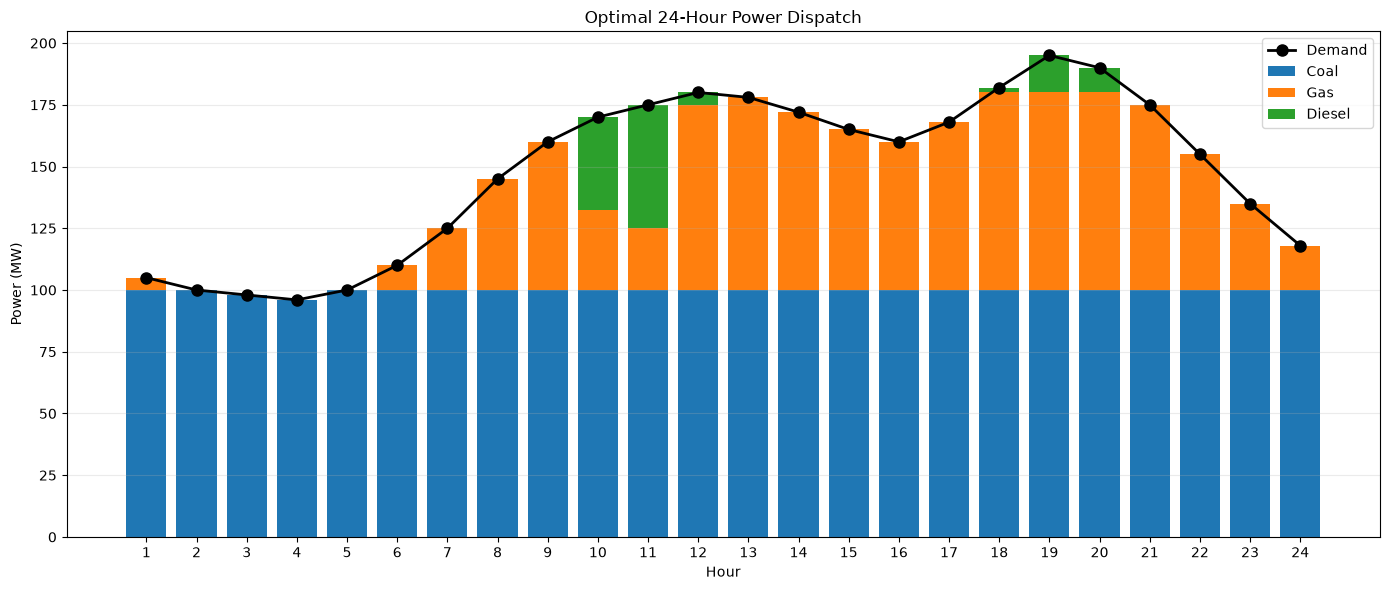

In [7]:
coal_power = df['Coal_Power_MW'].to_numpy()
gas_power = df['Gas_Power_MW'].to_numpy()
diesel_power = df['Diesel_Power_MW'].to_numpy()
demand_plot = df['Demand_MW'].to_numpy()

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(hours, coal_power, label='Coal')
ax.bar(hours, gas_power, bottom=coal_power, label='Gas')
ax.bar(hours, diesel_power, bottom=coal_power + gas_power, label='Diesel')

ax.plot(hours, demand_plot, color='black', marker='o', linewidth=2, markersize=8, label='Demand')

ax.set_title('Optimal 24-Hour Power Dispatch')
ax.set_xlabel('Hour')
ax.set_ylabel('Power (MW)')
ax.set_xticks(hours)
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

Because fuel prices vary by hour, the optimizer may buy extra fuel during cheaper hours and store it for later use. The model balances procurement cost, inventory limits, hourly purchase limits, generator capacities, and electricity demand while remaining a linear program.